# Module 7 — Integration: CNN + Fuzzy Enhancement

This notebook ties everything together into a single `ImageEnhancer` class.

## Pipeline

```
Input image
    │
    ├─► feature_extractor  →  260-d vector
    │                              │
    │                         CNN model
    │                              │
    │                    brightness / contrast / gamma
    │                              │
    │                       Fuzzy system
    │                    (refines the params)
    │                              │
    └──────────────────────► OpenCV enhancement
                                   │
                            Enhanced image
```

**OpenCV alpha-beta transform:**  
`output = clip(alpha × input + beta, 0, 255)`  
followed by **LUT-based gamma correction**.


In [1]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from config            import Config
from feature_extractor import extract_features, features_to_vector
from cnn_model         import EnhancementCNN
from fuzzy_system      import FuzzyEnhancementSystem

print("Imports successful.")

Imports successful.


In [ ]:
#Core enhancement functions 

def apply_enhancement(image: np.ndarray,
                      brightness_factor: float,
                      contrast_factor:   float,
                      gamma:             float) -> np.ndarray:
    
    # Alpha-beta transform 
    beta     = int((brightness_factor - 1.0) * 50)   # [-50, +50] pixel shift
    alpha    = contrast_factor
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

    #Gamma correction via LUT (fast: precompute once for all 256 values) 
    inv_gamma = 1.0 / max(gamma, 0.1)
    lut = np.array([
        np.clip(((i / 255.0) ** inv_gamma) * 255, 0, 255)
        for i in range(256)
    ], dtype=np.uint8)

    return cv2.LUT(adjusted, lut)


print("apply_enhancement() defined.")

apply_enhancement() defined.


In [3]:
#ImageEnhancer class
class ImageEnhancer:
    

    def __init__(self, model_path: str = Config.MODEL_SAVE_PATH):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Load CNN
        self.cnn = EnhancementCNN()
        self.cnn.load_state_dict(torch.load(model_path, map_location="cpu"))
        self.cnn.eval()
        self.cnn.to(self.device)

        # Fuzzy inference system
        self.fis = FuzzyEnhancementSystem()

        print(f"[Enhancer] CNN loaded from '{model_path}'")
        print(f"[Enhancer] Fuzzy system initialised.")

    # Main enhancement pipeline

    def enhance(self, image: np.ndarray) -> tuple:
        
        # 1. Feature extraction
        gray  = self._to_gray(image)
        feats = extract_features(gray)
        vec   = features_to_vector(feats)

        # 2. CNN predicts enhancement parameters
        x_tensor   = torch.tensor(vec, dtype=torch.float32).unsqueeze(0).to(self.device)
        raw_params = self.cnn.predict_params(x_tensor)

        bf = float(raw_params["brightness_factor"][0])
        cf = float(raw_params["contrast_factor"][0])
        g  = float(raw_params["gamma"][0])

        # 3. Fuzzy refinement based on raw image statistics
        norm_b = np.clip(feats["mean"] / 255.0, 0.0, 1.0)
        norm_c = np.clip(feats["std"] / 255.0, 0.0, 1.0)

        fuzzy_result = self.fis.infer(norm_b, norm_c)
        adjustment   = fuzzy_result["adjustment"]      # in [-1, 1]

        # Map adjustment to a multiplicative scale
        # adjustment=0  → scale=1.0 (no change)
        # adjustment=1  → scale=1.5 (boost by 50 %)
        # adjustment=-1 → scale=0.5 (reduce by 50 %)
        fuzzy_scale = 1.0 + 0.5 * adjustment
        bf = np.clip(bf * fuzzy_scale, *Config.BRIGHTNESS_RANGE)
        cf = np.clip(cf * fuzzy_scale, *Config.CONTRAST_RANGE)

        # 4. Apply OpenCV enhancement
        enhanced = apply_enhancement(image, bf, cf, g)

        info = {
            "features":          feats,
            "brightness_factor": bf,
            "contrast_factor":   cf,
            "gamma":             g,
            "fuzzy_adjustment":  adjustment,
            "fuzzy_scale":       fuzzy_scale,
            "active_rules":      fuzzy_result["active_rules"],
        }

        return enhanced, info

    def enhance_fuzzy_only(self, image: np.ndarray) -> tuple:
        
        gray  = self._to_gray(image)
        feats = extract_features(gray)

        fuzzy_result = self.fis.infer(feats["mean"], feats["std"])
        adjustment   = fuzzy_result["adjustment"]
        fuzzy_scale  = 1.0 + 0.5 * adjustment

        enhanced = apply_enhancement(image,
                                     brightness_factor=1.0 * fuzzy_scale,
                                     contrast_factor=1.0   * fuzzy_scale,
                                     gamma=1.0)
        return enhanced, fuzzy_result

    @staticmethod
    def _to_gray(image: np.ndarray) -> np.ndarray:
        if image.ndim == 3:
            return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return image


print("ImageEnhancer class defined.")

ImageEnhancer class defined.


In [4]:
#Demo: create a synthetic dark image and enhance it

import os

# Use sample.jpg if it exists, otherwise generate synthetic
if os.path.exists(Config.SAMPLE_IMAGE):
    original = cv2.imread(Config.SAMPLE_IMAGE)
    original = cv2.resize(original, Config.IMAGE_SIZE)
    print(f"Loaded '{Config.SAMPLE_IMAGE}'.")
else:
    print("No sample image found — generating synthetic dark image.")
    np.random.seed(7)
    base     = np.random.randint(20, 90, (*Config.IMAGE_SIZE, 3), dtype=np.uint8)
    original = cv2.GaussianBlur(base, (9, 9), 0)
    cv2.imwrite(Config.SAMPLE_IMAGE, original)

print(f"Image shape: {original.shape}  dtype: {original.dtype}")

Loaded 'sample.png'.
Image shape: (128, 128, 3)  dtype: uint8


In [5]:
# Run enhancement

enhancer = ImageEnhancer(model_path=Config.MODEL_SAVE_PATH)

cnn_fuzzy_img, info  = enhancer.enhance(original)
fuzzy_only_img, _    = enhancer.enhance_fuzzy_only(original)

print("\n── CNN-predicted parameters ──")
print(f"  Brightness factor : {info['brightness_factor']:.3f}")
print(f"  Contrast factor   : {info['contrast_factor']:.3f}")
print(f"  Gamma             : {info['gamma']:.3f}")
print(f"  Fuzzy adjustment  : {info['fuzzy_adjustment']:.4f}")
print(f"  Fuzzy scale       : {info['fuzzy_scale']:.3f}")
print(f"  Active rules      : {len(info['active_rules'])}")
for r in info["active_rules"]:
    print(f"    {r['rule']}  [str={r['strength']}]")

[Enhancer] CNN loaded from 'cnn_enhancer.pth'
[Enhancer] Fuzzy system initialised.

── CNN-predicted parameters ──
  Brightness factor : 2.000
  Contrast factor   : 2.000
  Gamma             : 0.857
  Fuzzy adjustment  : 0.5000
  Fuzzy scale       : 1.250
  Active rules      : 1
    IF dark AND low -> increase  [str=1.0]


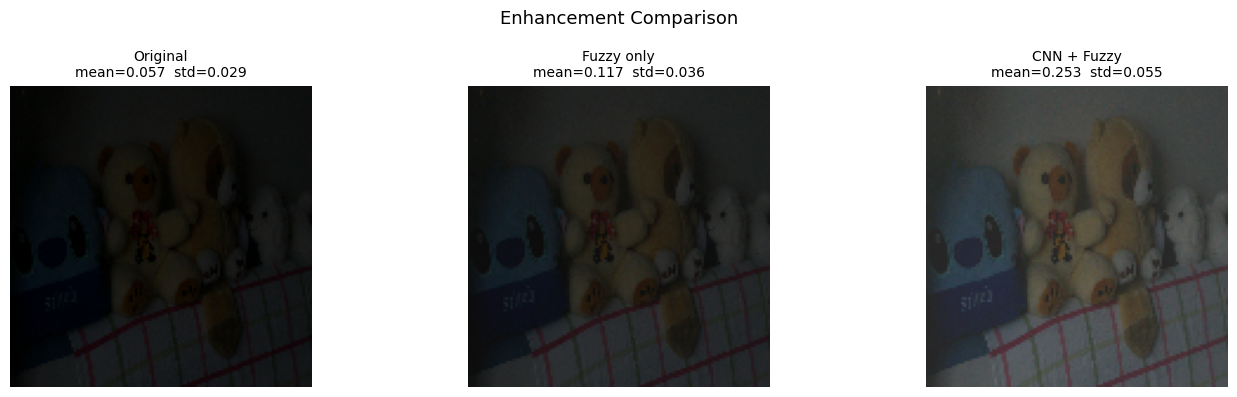

Saved enhancement_preview.png


In [9]:
#comparison

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, img, title in zip(
    axes,
    [original, fuzzy_only_img, cnn_fuzzy_img],
    ["Original", "Fuzzy only", "CNN + Fuzzy"],
):
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    ax.imshow(disp)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    ax.set_title(f"{title}\nmean={gray.mean()/255:.3f}  std={gray.std()/255:.3f}",
                 fontsize=10)
    ax.axis("off")

plt.suptitle("Enhancement Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("enhancement_preview.png", dpi=120)
plt.show()
print("Saved enhancement_preview.png")

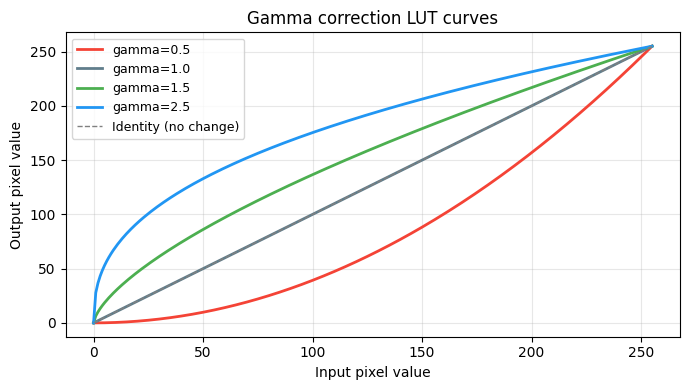

Saved gamma_lut.png


In [11]:
#Test gamma LUT effect 

x    = np.linspace(0, 255, 256)
fig, ax = plt.subplots(figsize=(7, 4))

for gamma_val, color in [(0.5, "#F44336"), (1.0, "#607D8B"), (1.5, "#4CAF50"), (2.5, "#2196F3")]:
    inv_g = 1.0 / max(gamma_val, 0.1)
    lut   = ((x / 255.0) ** inv_g) * 255
    ax.plot(x, lut, label=f"gamma={gamma_val}", color=color, linewidth=2)

ax.plot([0, 255], [0, 255], "--", color="gray", linewidth=1, label="Identity (no change)")
ax.set_xlabel("Input pixel value")
ax.set_ylabel("Output pixel value")
ax.set_title("Gamma correction LUT curves")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gamma_lut.png", dpi=120)
plt.show()
print("Saved gamma_lut.png")

In [15]:
# Save module to disk
import inspect

source = """
import cv2, numpy as np, torch
from config import Config
from feature_extractor import extract_features, features_to_vector
from cnn_model import EnhancementCNN
from fuzzy_system import FuzzyEnhancementSystem

def apply_enhancement(image: np.ndarray,
                      brightness_factor: float,
                      contrast_factor:   float,
                      gamma:             float) -> np.ndarray:
    
    # Alpha-beta transform 
    beta     = int((brightness_factor - 1.0) * 50)   # [-50, +50] pixel shift
    alpha    = contrast_factor
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

    #Gamma correction via LUT (fast: precompute once for all 256 values) 
    inv_gamma = 1.0 / max(gamma, 0.1)
    lut = np.array([
        np.clip(((i / 255.0) ** inv_gamma) * 255, 0, 255)
        for i in range(256)
    ], dtype=np.uint8)

    return cv2.LUT(adjusted, lut)


class ImageEnhancer:
    

    def __init__(self, model_path: str = Config.MODEL_SAVE_PATH):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

       
        self.cnn = EnhancementCNN()
        self.cnn.load_state_dict(torch.load(model_path, map_location="cpu"))
        self.cnn.eval()
        self.cnn.to(self.device)

        
        self.fis = FuzzyEnhancementSystem()

        print(f"[Enhancer] CNN loaded from '{model_path}'")
        print(f"[Enhancer] Fuzzy system initialised.")

    

    def enhance(self, image: np.ndarray) -> tuple:
        
        
        gray  = self._to_gray(image)
        feats = extract_features(gray)
        vec   = features_to_vector(feats)

        
        x_tensor   = torch.tensor(vec, dtype=torch.float32).unsqueeze(0).to(self.device)
        raw_params = self.cnn.predict_params(x_tensor)

        bf = float(raw_params["brightness_factor"][0])
        cf = float(raw_params["contrast_factor"][0])
        g  = float(raw_params["gamma"][0])

        
        norm_b = np.clip(feats["mean"] / 255.0, 0.0, 1.0)
        norm_c = np.clip(feats["std"] / 255.0, 0.0, 1.0)

        fuzzy_result = self.fis.infer(norm_b, norm_c)
        adjustment   = fuzzy_result["adjustment"]      # in [-1, 1]

    
        fuzzy_scale = 1.0 + 0.5 * adjustment
        bf = np.clip(bf * fuzzy_scale, *Config.BRIGHTNESS_RANGE)
        cf = np.clip(cf * fuzzy_scale, *Config.CONTRAST_RANGE)

        
        enhanced = apply_enhancement(image, bf, cf, g)

        info = {
            "features":          feats,
            "brightness_factor": bf,
            "contrast_factor":   cf,
            "gamma":             g,
            "fuzzy_adjustment":  adjustment,
            "fuzzy_scale":       fuzzy_scale,
            "active_rules":      fuzzy_result["active_rules"],
        }

        return enhanced, info

    def enhance_fuzzy_only(self, image: np.ndarray) -> tuple:
        
        gray  = self._to_gray(image)
        feats = extract_features(gray)

        fuzzy_result = self.fis.infer(feats["mean"], feats["std"])
        adjustment   = fuzzy_result["adjustment"]
        fuzzy_scale  = 1.0 + 0.5 * adjustment

        enhanced = apply_enhancement(image,
                                     brightness_factor=1.0 * fuzzy_scale,
                                     contrast_factor=1.0   * fuzzy_scale,
                                     gamma=1.0)
        return enhanced, fuzzy_result

    @staticmethod
    def _to_gray(image: np.ndarray) -> np.ndarray:
        if image.ndim == 3:
            return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return image
"""

with open("enhancer.py", "w") as f:
    f.write(source)

print("enhancer.py written to disk.")

enhancer.py written to disk.
